# ============================================================
# COMPLETE ANN / MLP REGRESSION TEMPLATE
# ============================================================
#
# PURPOSE:
#   A reusable template for tabular regression problems.
#
# EXAMPLE:
#   Inputs  -> [l, d1, d2, H, T, ...]
#   Output  -> Power
#
# PIPELINE:
#
#   Raw Data
#       ↓
#   Clean / inspect
#       ↓
#   Train / Validation / Test split
#       ↓
#   Fit scaler ONLY on training data
#       ↓
#   Scale data
#       ↓
#   ANN / MLP
#       ↓
#   Forward propagation
#       ↓
#   Loss
#       ↓
#   Backpropagation
#       ↓
#   Optimizer
#       ↓
#   Weight update
#       ↓
#   Repeat for many batches / epochs
#       ↓
#   Validation
#       ↓
#   Early stopping / model selection
#       ↓
#   Test evaluation
#       ↓
#   Final predictions
#
# ============================================================

In [ ]:
from pip._internal.operations.freeze import freeze

# Generate and print the packages in 'freeze' format
for line in freeze(local_only=True):
    print(line)


In [1]:
import os
import random
import copy

import numpy as np
import pandas as pd
import matplotlib as mlt
import seaborn as sns

import torch
import torch.nn as nn #Also read
from torch.utils.data import TensorDataset , DataLoader # Read what they do

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , MinMaxScaler
from sklearn.metrics import (
    mean_squared_error, 
    mean_absolute_error,
    r2_score
)

In [2]:
"""Understand all"""

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ============================================================
# 3. CONFIGURATION CLASS
# ============================================================
#
# Keeping hyperparameters in one place makes tuning easier.
#
# Instead of searching through the entire program for:
#
#     learning_rate = ...
#     batch_size = ...
#     dropout = ...
#
# everything is controlled here.
# ============================================================

In [3]:
class Config:
    DATA_PATH = "data/Simulation_Data.csv"
    FEATURES = [
        # "feature_1",
        # "feature_2",
        # "feature_3"
        #more
        "l1", "d1", "d2", "a1", "m1", "Qi"
    ]

    TARGET = "P_ext"

    TRAIN_RATIO = 0.70
    VAL_RATIO = 0.15
    TEST_RATIO = 0.15

    """
    Input Scaling -
    1. StandardScaling
    2. MinMaxScaling
    3. None
    """

    INPUT_SCALER = "standard"

    TARGET_SCALER = "standard"

    """
    64 -> 32 -> 16 neurons
    """

    HIDDEN_LAYERS = [64 , 32 , 16]

    """ 
    Activation Functions -
    1. relu
    2. tanh
    3. sigmoid 
    4. leaky_relu
    5. elu
    6. gelu
    """

    ACTIVATION = "relu"

    """ 
    OUTPUT ACTIVATION
    1. linear
    2. sigmoid
    3. tanh
    """

    OUTPUT_ACTIVATION = "linear"

    #DROPOUT -> understand for regularization

    DROPOUT = 0.0

    #Weight Initialization -> Understand

    INITIALIZATION = "he"


    #TRAINING
    MAX_EPOCHS = 100

    BATCH_SIZE = 64 #16 , 32 , 64 , 128 , 256 

    OPTIMIZER = "adam"

    LEARNING_RATE = 1e-4

    #Momentum ?
    MOMENTUM = 0.9

    #Weight Decay??
    WEIGHT_DECAY = 0.0

    #L1 Regularization
    L1_LAMBDA = 0.0

    LOSS_FUNCTION = "mse" # mae , huber

    EARLY_STOPPING = True

    PATIENCE = 10 #Number of epochs to wait for improvement

    MIN_DELTA = 1e-6 #Minimum improvement required

    #Learning Rate Scheduler ? -> none , reduceonplateau

    LR_SCHEDULER = "none"


    #if reduceonplateau
    LR_FACTOR = 0.5
    LR_PATIENCE = 1.0

    DEVICE = torch.device(
        "cuda" if torch.cuda.is_available() else "cpu"
    )


print("Using device: \t" , Config.DEVICE)
print("Hidden Layers: \t" , Config.HIDDEN_LAYERS)
print("Activation: \t" , Config.ACTIVATION)
print("Optimizer: \t" , Config.OPTIMIZER)
print("Learning Rate: \t" ,Config.LEARNING_RATE)
print("Max Epochs: \t" ,Config.MAX_EPOCHS)
print("Batch Size: \t", Config.BATCH_SIZE)


Using device: 	 cuda
Hidden Layers: 	 [64, 32, 16]
Activation: 	 relu
Optimizer: 	 adam
Learning Rate: 	 0.0001
Max Epochs: 	 100
Batch Size: 	 64


In [4]:
df = pd.read_csv(Config.DATA_PATH)

print("\nDataset shape:", df.shape)
print("\nFirst rows:")
print(df.head())


Dataset shape: (360720, 15)

First rows:
   l1   d1   d2   a1  m1    Qi        w1        w2          B        P_ext  \
0  15  1.0  1.5  0.0   1  4.00  0.148368  0.148368  15.296736   683.605075   
1  15  1.0  1.5  0.0   1  4.01  0.148368  0.148368  15.296736   818.774546   
2  15  1.0  1.5  0.0   1  4.02  0.148368  0.148368  15.296736   957.229377   
3  15  1.0  1.5  0.0   1  4.03  0.148368  0.148368  15.296736  1052.501526   
4  15  1.0  1.5  0.0   1  4.04  0.148368  0.148368  15.296736  1045.885291   

   eta_maxx      REFL     TRANS       chi         P_inc  
0  0.040956  0.001986  0.957058  1.058575  16691.239305  
1  0.048889  0.002274  0.948837  1.058736  16747.518448  
2  0.056965  0.002504  0.940531  1.058887  16803.960161  
3  0.062424  0.002557  0.935019  1.059028  16860.562837  
4  0.061823  0.002329  0.935848  1.059159  16917.324821  


In [5]:
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic statistics:")
print(df.describe())


Data types:
l1            int64
d1          float64
d2          float64
a1          float64
m1            int64
Qi          float64
w1          float64
w2          float64
B           float64
P_ext       float64
eta_maxx    float64
REFL        float64
TRANS       float64
chi         float64
P_inc       float64
dtype: object

Missing values:
l1          0
d1          0
d2          0
a1          0
m1          0
Qi          0
w1          0
w2          0
B           0
P_ext       0
eta_maxx    0
REFL        0
TRANS       0
chi         0
P_inc       0
dtype: int64

Basic statistics:
                  l1             d1             d2             a1  \
count  360720.000000  360720.000000  360720.000000  360720.000000   
mean       22.500000       1.500000       2.000000       0.750000   
std         5.590178       0.408249       0.408249       0.559018   
min        15.000000       1.000000       1.500000       0.000000   
25%        18.750000       1.000000       1.500000       0.375000   


In [6]:
# Remove rows where P_ext is outside the valid range [0, 10,000]
df = df[(df["P_ext"] >= 0) & (df["P_ext"] <= 10_000)].reset_index(drop=True)

In [7]:
print("\nBasic statistics:")
print(df.describe())


Basic statistics:
                  l1             d1             d2             a1  \
count  294384.000000  294384.000000  294384.000000  294384.000000   
mean       22.709794       1.412169       2.083659       0.768433   
std         5.591651       0.390633       0.394202       0.558154   
min        15.000000       1.000000       1.500000       0.000000   
25%        20.000000       1.000000       2.000000       0.500000   
50%        25.000000       1.500000       2.000000       1.000000   
75%        30.000000       1.500000       2.500000       1.500000   
max        30.000000       2.000000       2.500000       1.500000   

                 m1             Qi             w1             w2  \
count  294384.00000  294384.000000  294384.000000  294384.000000   
mean        2.94624       6.457623       0.138180       0.138180   
std         1.41914       1.442406       0.006881       0.006881   
min         1.00000       4.000000       0.130913       0.130913   
25%         2.00000

In [8]:
X = df[Config.FEATURES].values
y = df[Config.TARGET].values

In [9]:
X = X.astype(np.float32)
y = y.astype(np.float32)

In [10]:
# 10. TRAIN / VALIDATION / TEST SPLIT
#
# First:
#
#     Train + Temporary
#
# Then split temporary into:
#
#     Validation + Test
#
# This gives:
#
#     70% train
#     15% validation
#     15% test


X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=(Config.VAL_RATIO + Config.TEST_RATIO),
    random_state=SEED
)

# Fraction of temporary data that should become test data.
temp_test_ratio = (
    Config.TEST_RATIO /
    (Config.VAL_RATIO + Config.TEST_RATIO)
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=temp_test_ratio,
    random_state=SEED
)


print("\nSplit sizes:")
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)



Split sizes:
Train: (206068, 6)
Validation: (44158, 6)
Test: (44158, 6)


In [11]:
input_scaler = None
target_scaler = None

In [12]:
if Config.INPUT_SCALER == "standard":

    input_scaler = StandardScaler()

    input_scaler.fit(X_train)

elif Config.INPUT_SCALER == "minmax":

    input_scaler = MinMaxScaler()

    input_scaler.fit(X_train)

elif Config.INPUT_SCALER is None:

    input_scaler = None

else:

    raise ValueError("Unknown input scaler")

In [13]:
if input_scaler is not None:

    X_train = input_scaler.transform(X_train)
    X_val = input_scaler.transform(X_val)
    X_test = input_scaler.transform(X_test)

In [14]:
if Config.TARGET_SCALER == "standard":

    target_scaler = StandardScaler()

    # sklearn expects 2D input
    target_scaler.fit(y_train.reshape(-1, 1))

elif Config.TARGET_SCALER == "minmax":

    target_scaler = MinMaxScaler()

    target_scaler.fit(y_train.reshape(-1, 1))

elif Config.TARGET_SCALER is None:

    target_scaler = None

else:

    raise ValueError("Unknown target scaler")


In [15]:
if target_scaler is not None:

    y_train = target_scaler.transform(
        y_train.reshape(-1, 1)
    ).flatten()

    y_val = target_scaler.transform(
        y_val.reshape(-1, 1)
    ).flatten()

    y_test = target_scaler.transform(
        y_test.reshape(-1, 1)
    ).flatten()

In [16]:
# 16. CONVERT NUMPY → PYTORCH TENSORS

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(
    y_train.reshape(-1, 1),
    dtype=torch.float32
)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(
    y_val.reshape(-1, 1),
    dtype=torch.float32
)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(
    y_test.reshape(-1, 1),
    dtype=torch.float32
)

In [19]:
print(X_train_tensor[0].shape)

torch.Size([6])


In [20]:
print(y_train_tensor[0].shape)

torch.Size([1])


In [17]:
#Create Datasets

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

In [21]:
#Create DATALOADERS

# batch_size determines how many samples are processed
# before one optimizer update.
#
# shuffle=True:
#
# Training samples are shuffled every epoch.
#
# Validation/test:
#
# Usually shuffle=False.

train_loader = DataLoader(
    train_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False
)


In [22]:
def get_activation(name):

    name = name.lower()

    if name == "relu":
        return nn.ReLU()

    elif name == "tanh":
        return nn.Tanh()

    elif name == "sigmoid":
        return nn.Sigmoid()

    elif name == "leaky_relu":
        return nn.LeakyReLU()

    elif name == "elu":
        return nn.ELU()

    elif name == "gelu":
        return nn.GELU()

    else:
        raise ValueError(
            f"Unknown activation: {name}"
        )


In [23]:
def get_output_activation(name):

    name = name.lower()

    if name == "linear":
        return nn.Identity()

    elif name == "sigmoid":
        return nn.Sigmoid()

    elif name == "tanh":
        return nn.Tanh()

    else:
        raise ValueError(
            f"Unknown output activation: {name}"
        )


In [ ]:
# This class constructs the network dynamically.
#
# Example:
#
# HIDDEN_LAYERS = [64, 32, 16]
#
# becomes:
#
# Input
#   ↓
# Dense(64)
#   ↓
# ReLU
#   ↓
# Dense(32)
#   ↓
# ReLU
#   ↓
# Dense(16)
#   ↓
# ReLU
#   ↓
# Dense(1)
#   ↓
# Linear

In [24]:
class ANN(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_layers,
        output_size=1,
        activation="relu",
        dropout=0.0,
        output_activation="linear",
        initialization="he"
    ):

        super().__init__()

        layers = []

        previous_size = input_size
        # CREATE HIDDEN LAYERS
    
        for hidden_size in hidden_layers:

            # Dense / Fully Connected layer
            layers.append(
                nn.Linear(
                    previous_size,
                    hidden_size
                )
            )

            # Activation
            layers.append(
                get_activation(activation)
            )

            # Optional dropout
            if dropout > 0:

                layers.append(
                    nn.Dropout(dropout)
                )

            previous_size = hidden_size

        # OUTPUT LAYER

        layers.append(
            nn.Linear(
                previous_size,
                output_size
            )
        )

        # Output activation
        layers.append(
            get_output_activation(output_activation)
        )

        # Convert list to PyTorch sequential model
        self.network = nn.Sequential(*layers)

        # Initialize weights
        self.initialize_weights(initialization)


    # WEIGHT INITIALIZATION

    def initialize_weights(self, method):

        for layer in self.network:

            if isinstance(layer, nn.Linear):

                if method == "he":

                    # He initialization
                    #
                    # Particularly common with ReLU.
                    nn.init.kaiming_normal_(
                        layer.weight,
                        nonlinearity="relu"
                    )

                elif method == "xavier":

                    # Xavier / Glorot initialization
                    nn.init.xavier_normal_(
                        layer.weight
                    )

                elif method == "default":

                    # PyTorch's default initialization
                    pass

                else:

                    raise ValueError(
                        "Unknown initialization method"
                    )

                # Bias initialization
                nn.init.zeros_(layer.bias)


    # FORWARD PROPAGATION

    def forward(self, x):

        return self.network(x)


In [25]:
input_size = X_train.shape[1]

model = ANN(
    input_size=input_size,
    hidden_layers=Config.HIDDEN_LAYERS,
    output_size=1,
    activation=Config.ACTIVATION,
    dropout=Config.DROPOUT,
    output_activation=Config.OUTPUT_ACTIVATION,
    initialization=Config.INITIALIZATION
)

model = model.to(Config.DEVICE)

In [26]:
print("\nModel:")
print(model)


Model:
ANN(
  (network): Sequential(
    (0): Linear(in_features=6, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Identity()
  )
)


In [27]:
def get_loss_function(name):

    name = name.lower()

    if name == "mse":

        return nn.MSELoss()

    elif name == "mae":

        return nn.L1Loss()

    elif name == "huber":

        return nn.HuberLoss()

    else:

        raise ValueError(
            f"Unknown loss function: {name}"
        )


criterion = get_loss_function(
    Config.LOSS_FUNCTION
)


In [28]:
def get_optimizer(model):

    if Config.OPTIMIZER.lower() == "adam":

        return torch.optim.Adam(
            model.parameters(),
            lr=Config.LEARNING_RATE,
            weight_decay=Config.WEIGHT_DECAY
        )

    elif Config.OPTIMIZER.lower() == "adamw":

        return torch.optim.AdamW(
            model.parameters(),
            lr=Config.LEARNING_RATE,
            weight_decay=Config.WEIGHT_DECAY
        )

    elif Config.OPTIMIZER.lower() == "sgd":

        return torch.optim.SGD(
            model.parameters(),
            lr=Config.LEARNING_RATE,
            momentum=Config.MOMENTUM,
            weight_decay=Config.WEIGHT_DECAY
        )

    elif Config.OPTIMIZER.lower() == "rmsprop":

        return torch.optim.RMSprop(
            model.parameters(),
            lr=Config.LEARNING_RATE,
            weight_decay=Config.WEIGHT_DECAY
        )

    else:

        raise ValueError(
            f"Unknown optimizer: {Config.OPTIMIZER}"
        )


optimizer = get_optimizer(model)

In [29]:
if Config.LR_SCHEDULER == "reduce_on_plateau":

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=Config.LR_FACTOR,
        patience=Config.LR_PATIENCE
    )

else:

    scheduler = None


In [30]:
def calculate_l1_penalty(model):

    l1_penalty = torch.tensor(
        0.0,
        device=Config.DEVICE
    )

    for parameter in model.parameters():

        l1_penalty += torch.sum(
            torch.abs(parameter)
        )

    return Config.L1_LAMBDA * l1_penalty

In [31]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    total_loss = 0.0

    total_samples = 0

    for X_batch, y_batch in loader:

        # Move data to CPU/GPU
        X_batch = X_batch.to(Config.DEVICE)
        y_batch = y_batch.to(Config.DEVICE)

        # 1. FORWARD PROPAGATION

        predictions = model(X_batch)

        # 2. CALCULATE LOSS

        loss = criterion(
            predictions,
            y_batch
        )

        # 3. ADD L1 REGULARIZATION

        if Config.L1_LAMBDA > 0:

            loss += calculate_l1_penalty(model)

        # 4. CLEAR OLD GRADIENTS

        optimizer.zero_grad()

        # 5. BACKPROPAGATION

        loss.backward()

        # 6. UPDATE WEIGHTS

        optimizer.step()

        # ACCUMULATE LOSS

        batch_size = X_batch.size(0)

        total_loss += loss.item() * batch_size

        total_samples += batch_size

    return total_loss / total_samples

In [32]:
def validate(
    model,
    loader,
    criterion
):

    model.eval()

    total_loss = 0.0
    total_samples = 0

    # Disable gradient calculations.
    #
    # This saves memory and computation.
    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(Config.DEVICE)
            y_batch = y_batch.to(Config.DEVICE)

            predictions = model(X_batch)

            loss = criterion(
                predictions,
                y_batch
            )

            batch_size = X_batch.size(0)

            total_loss += loss.item() * batch_size

            total_samples += batch_size

    return total_loss / total_samples

In [33]:
class EarlyStopping:

    def __init__(
        self,
        patience=10,
        min_delta=0.0
    ):

        self.patience = patience

        self.min_delta = min_delta

        self.best_loss = float("inf")

        self.counter = 0

        self.best_state = None

        self.should_stop = False


    def step(self, validation_loss, model):

        # Check whether validation loss improved.
        if validation_loss < (
            self.best_loss - self.min_delta
        ):

            self.best_loss = validation_loss

            self.counter = 0

            # Save best model parameters
            self.best_state = copy.deepcopy(
                model.state_dict()
            )

        else:

            self.counter += 1

            if self.counter >= self.patience:

                self.should_stop = True


In [34]:
def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler=None
):

    history = {

        "train_loss": [],

        "val_loss": [],

        "learning_rate": []
    }

    # EARLY STOPPING

    early_stopper = EarlyStopping(
        patience=Config.PATIENCE,
        min_delta=Config.MIN_DELTA
    )

    # EPOCH LOOP

    for epoch in range(
        1,
        Config.MAX_EPOCHS + 1
    ):

        # TRAINING

        train_loss = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        # VALIDATION

        val_loss = validate(
            model,
            val_loader,
            criterion
        )

        # LEARNING RATE SCHEDULER

        if scheduler is not None:

            scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]["lr"]

        # SAVE HISTORY

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        history["learning_rate"].append(
            current_lr
        )

        # PRINT PROGRESS

        if (
            epoch == 1
            or epoch % 10 == 0
        ):

            print(
                f"Epoch {epoch:4d} | "
                f"Train Loss: {train_loss:.6f} | "
                f"Val Loss: {val_loss:.6f} | "
                f"LR: {current_lr:.2e}"
            )

        # EARLY STOPPING

        if Config.EARLY_STOPPING:

            early_stopper.step(
                val_loss,
                model
            )

            if early_stopper.should_stop:

                print(
                    f"\nEarly stopping at epoch {epoch}"
                )

                break

    # RESTORE BEST MODEL

    if (
        Config.EARLY_STOPPING
        and early_stopper.best_state is not None
    ):

        model.load_state_dict(
            early_stopper.best_state
        )

        print(
            "Best validation model restored."
        )

    return history


In [35]:
history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler
)

Epoch    1 | Train Loss: 0.994512 | Val Loss: 0.977160 | LR: 1.00e-04
Epoch   10 | Train Loss: 0.894285 | Val Loss: 0.923739 | LR: 1.00e-04
Epoch   20 | Train Loss: 0.820747 | Val Loss: 0.847330 | LR: 1.00e-04
Epoch   30 | Train Loss: 0.726729 | Val Loss: 0.753120 | LR: 1.00e-04
Epoch   40 | Train Loss: 0.643533 | Val Loss: 0.663437 | LR: 1.00e-04
Epoch   50 | Train Loss: 0.573302 | Val Loss: 0.591998 | LR: 1.00e-04
Epoch   60 | Train Loss: 0.515127 | Val Loss: 0.529700 | LR: 1.00e-04
Epoch   70 | Train Loss: 0.465612 | Val Loss: 0.479200 | LR: 1.00e-04
Epoch   80 | Train Loss: 0.425735 | Val Loss: 0.437617 | LR: 1.00e-04
Epoch   90 | Train Loss: 0.391439 | Val Loss: 0.406068 | LR: 1.00e-04
Epoch  100 | Train Loss: 0.362149 | Val Loss: 0.373456 | LR: 1.00e-04
Best validation model restored.


In [36]:
def predict(
    model,
    X
):

    model.eval()

    # Convert numpy → tensor
    X_tensor = torch.tensor(
        X,
        dtype=torch.float32
    )

    X_tensor = X_tensor.to(
        Config.DEVICE
    )

    with torch.no_grad():

        predictions = model(
            X_tensor
        )

    return predictions.cpu().numpy().flatten()

In [37]:
test_predictions_scaled = predict(
    model,
    X_test
)

In [38]:
if target_scaler is not None:

    test_predictions = target_scaler.inverse_transform(
        test_predictions_scaled.reshape(-1, 1)
    ).flatten()

    y_test_original = target_scaler.inverse_transform(
        y_test.reshape(-1, 1)
    ).flatten()

else:

    test_predictions = test_predictions_scaled

    y_test_original = y_test

In [39]:
def calculate_metrics(
    actual,
    predicted
):

    mse = mean_squared_error(
        actual,
        predicted
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        actual,
        predicted
    )

    r2 = r2_score(
        actual,
        predicted
    )

    return {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }


test_metrics = calculate_metrics(
    y_test_original,
    test_predictions
)


In [40]:
print("FINAL TEST PERFORMANCE")


for metric_name, value in test_metrics.items():

    print(
        f"{metric_name:>6}: {value:.6f}"
    )

FINAL TEST PERFORMANCE
   MSE: 345082.937500
  RMSE: 587.437603
   MAE: 369.024078
    R2: 0.628448


In [41]:
results = pd.DataFrame({

    "Actual": y_test_original,

    "Predicted": test_predictions,

    "Error": (
        y_test_original
        - test_predictions
    ),

    "Absolute_Error": np.abs(
        y_test_original
        - test_predictions
    )
})

print("\nPrediction examples:")
print(results.head(20))


Prediction examples:
         Actual    Predicted        Error  Absolute_Error
0   1445.431274  1805.629272  -360.197998      360.197998
1   1609.829590  1475.283325   134.546265      134.546265
2     45.474487    94.291321   -48.816833       48.816833
3    272.047943   907.877319  -635.829346      635.829346
4    296.780518    31.687561   265.092957      265.092957
5   1143.733032   426.873779   716.859253      716.859253
6    861.791992  1372.206299  -510.414307      510.414307
7     46.407043    23.638306    22.768738       22.768738
8    434.888947   706.630798  -271.741852      271.741852
9    810.610962  2056.232666 -1245.621704     1245.621704
10  2166.254883  1092.586792  1073.668091     1073.668091
11   182.697662   489.089478  -306.391815      306.391815
12   264.709229   200.423370    64.285858       64.285858
13  1109.996460  1089.289062    20.707397       20.707397
14    58.428711   197.079010  -138.650299      138.650299
15    60.072205   581.735962  -521.663757      521

In [42]:
torch.save(
    model.state_dict(),
    "ann_model.pth"
)

print("\nModel saved as ann_model.pth")


Model saved as ann_model.pth


In [43]:
results.to_csv(
    "ann_test_predictions.csv",
    index=False
)

In [44]:
history_df = pd.DataFrame(history)

history_df.to_csv(
    "ann_training_history.csv",
    index=False
)

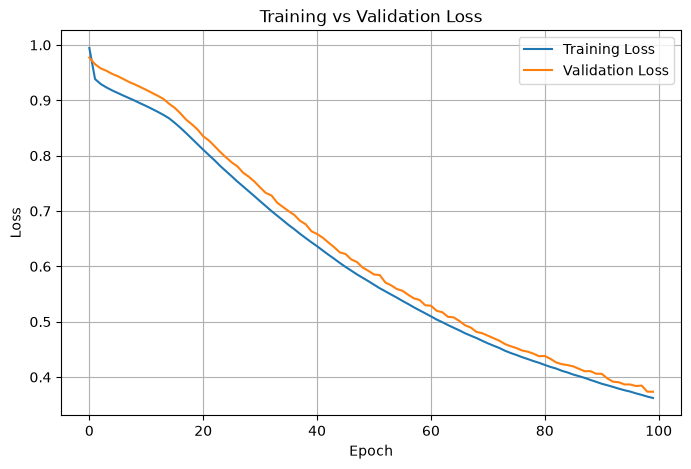

In [45]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 5))

plt.plot(
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()


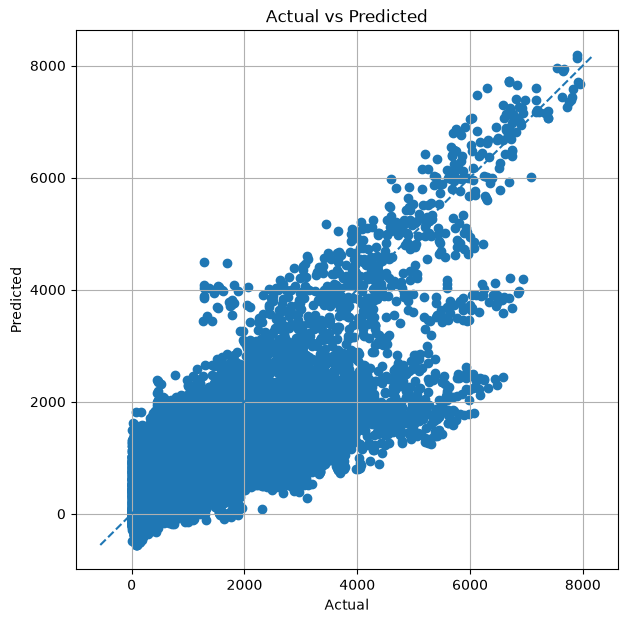

In [46]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test_original,
    test_predictions
)

minimum = min(
    y_test_original.min(),
    test_predictions.min()
)

maximum = max(
    y_test_original.max(),
    test_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

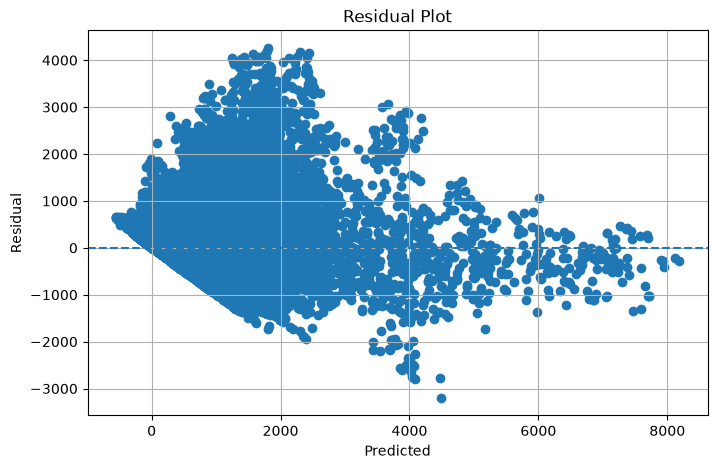

In [47]:
residuals = (
    y_test_original
    - test_predictions
)

plt.figure(figsize=(8, 5))

plt.scatter(
    test_predictions,
    residuals
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted")
plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

In [51]:
def run_experiment(
    hidden_layers,
    learning_rate,
    batch_size,
    activation="relu",
    dropout=0.0,
    optimizer_name="adam",
    loss_name="mse",
    weight_decay=0.0
):

    # Create fresh DataLoaders

    experiment_train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    experiment_val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )

    # Create fresh model

    experiment_model = ANN(
        input_size=X_train.shape[1],
        hidden_layers=hidden_layers,
        output_size=1,
        activation=activation,
        dropout=dropout,
        output_activation="linear",
        initialization="he"
    )

    experiment_model = experiment_model.to(
        Config.DEVICE
    )


    # Loss


    experiment_criterion = get_loss_function(
        loss_name
    )


    # Optimizer
  

    if optimizer_name == "adam":

        experiment_optimizer = torch.optim.Adam(
            experiment_model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    elif optimizer_name == "adamw":

        experiment_optimizer = torch.optim.AdamW(
            experiment_model.parameters(),
            lr=learning_rate,
            weight_decay=weight_decay
        )

    elif optimizer_name == "sgd":

        experiment_optimizer = torch.optim.SGD(
            experiment_model.parameters(),
            lr=learning_rate,
            momentum=0.9,
            weight_decay=weight_decay
        )

    else:

        raise ValueError(
            "Unsupported optimizer"
        )

        original_epochs = Config.MAX_EPOCHS

    # Keep experiments manageable.
    Config.MAX_EPOCHS = 200


    # Train

    experiment_history = train_model(
        experiment_model,
        experiment_train_loader,
        experiment_val_loader,
        experiment_criterion,
        experiment_optimizer
    )

    # Restore
    Config.MAX_EPOCHS = 300


    # Best validation loss


    best_val_loss = min(
        experiment_history["val_loss"]
    )

    return {
        "model": experiment_model,
        "history": experiment_history,
        "best_val_loss": best_val_loss
    }

In [52]:
# Here we vary ONLY architecture.
#
# Everything else remains approximately fixed.
#
# This is much better scientifically than changing:
#
#     layers
#     learning rate
#     dropout
#     optimizer
#     batch size
#
# simultaneously and then having no idea why performance
# changed.

In [53]:

# ============================================================
# 46. SYSTEMATIC ANN HYPERPARAMETER TUNING
# ============================================================
#
# IMPORTANT:
#
# We are NOT going to blindly test every possible combination.
#
# A complete Cartesian product such as:
#
# architectures × LR × batch size × activation × loss
# × optimizer × dropout × weight decay
#
# would create a huge number of experiments.
#
# Instead, we use STAGED / SEQUENTIAL TUNING.
#
# General strategy:
#
#   Stage 1 → Architecture
#   Stage 2 → Learning rate
#   Stage 3 → Batch size
#   Stage 4 → Activation
#   Stage 5 → Loss
#   Stage 6 → Optimizer
#   Stage 7 → Regularization
#   Stage 8 → Small final combination search
#
# Each stage uses the best result from the previous stage.
#
# This gives us a much smaller and more interpretable search.
# ============================================================


# ============================================================
# 46.1 HELPER FUNCTION
# ============================================================
#
# This function runs one experiment and returns:
#
#   - best validation loss
#   - trained model
#   - training history
#
# IMPORTANT:
#
# The TEST set is never used here.
#
# Hyperparameter selection is performed using VALIDATION data.
# ============================================================


def run_tuning_experiment(
    hidden_layers,
    learning_rate,
    batch_size,
    activation,
    dropout,
    optimizer_name,
    loss_name,
    weight_decay
):

    print("\n--------------------------------------------")

    print(
        "Architecture:",
        hidden_layers
    )

    print(
        "Learning rate:",
        learning_rate
    )

    print(
        "Batch size:",
        batch_size
    )

    print(
        "Activation:",
        activation
    )

    print(
        "Dropout:",
        dropout
    )

    print(
        "Optimizer:",
        optimizer_name
    )

    print(
        "Loss:",
        loss_name
    )

    print(
        "Weight decay:",
        weight_decay
    )

    print("--------------------------------------------")


    # --------------------------------------------------------
    # Create DataLoaders
    # --------------------------------------------------------

    tuning_train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True
    )

    tuning_val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False
    )


    # --------------------------------------------------------
    # Create fresh ANN
    # --------------------------------------------------------
    #
    # IMPORTANT:
    #
    # Every experiment must start with a NEW model.
    #
    # Otherwise the second experiment would inherit weights
    # from the first experiment.
    # --------------------------------------------------------

    tuning_model = ANN(

        input_size=X_train.shape[1],

        hidden_layers=hidden_layers,

        output_size=1,

        activation=activation,

        dropout=dropout,

        output_activation="linear",

        initialization="he"
    )


    tuning_model = tuning_model.to(
        Config.DEVICE
    )


    # --------------------------------------------------------
    # Loss
    # --------------------------------------------------------

    tuning_criterion = get_loss_function(
        loss_name
    )


    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    if optimizer_name == "adam":

        tuning_optimizer = torch.optim.Adam(

            tuning_model.parameters(),

            lr=learning_rate,

            weight_decay=weight_decay
        )


    elif optimizer_name == "adamw":

        tuning_optimizer = torch.optim.AdamW(

            tuning_model.parameters(),

            lr=learning_rate,

            weight_decay=weight_decay
        )


    elif optimizer_name == "sgd":

        tuning_optimizer = torch.optim.SGD(

            tuning_model.parameters(),

            lr=learning_rate,

            momentum=0.9,

            weight_decay=weight_decay
        )


    else:

        raise ValueError(
            f"Unknown optimizer: {optimizer_name}"
        )


    # --------------------------------------------------------
    # Temporarily reduce maximum epochs during tuning
    # --------------------------------------------------------
    #
    # We don't need 500 epochs for every candidate.
    #
    # Early stopping will stop models that stop improving.
    #
    # After selecting the final configuration, we can train
    # the final model properly.
    # --------------------------------------------------------

    original_epochs = Config.MAX_EPOCHS

    Config.MAX_EPOCHS = 200


    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    tuning_history = train_model(

        model=tuning_model,

        train_loader=tuning_train_loader,

        val_loader=tuning_val_loader,

        criterion=tuning_criterion,

        optimizer=tuning_optimizer,

        scheduler=None
    )


    # --------------------------------------------------------
    # Restore original epoch setting
    # --------------------------------------------------------

    Config.MAX_EPOCHS = original_epochs


    # --------------------------------------------------------
    # Best validation loss
    # --------------------------------------------------------

    best_val_loss = min(
        tuning_history["val_loss"]
    )


    return {

        "model": tuning_model,

        "history": tuning_history,

        "best_val_loss": best_val_loss
    }


# ============================================================
# 47. STAGE 1 — ARCHITECTURE SEARCH
# ============================================================
#
# We intentionally reduced the original architecture list.
#
# TEST:
#
#   [32]
#   [64, 32]
#   [128, 64, 32]
#   [64, 32, 16]
#
# Why these?
#
# [32]
#     Small baseline.
#
# [64,32]
#     Moderate and relatively simple.
#
# [128,64,32]
#     Higher-capacity network.
#
# [64,32,16]
#     Gradually narrowing architecture.
#
# We remove [16] because it is an extremely small model for
# a potentially complicated nonlinear surrogate.
#
# We also don't test many arbitrary layer combinations.
#
# Everything else is held constant.
# ============================================================


architecture_candidates = [

    [32],

    [64, 32],

    [128, 64, 32],

    [64, 32, 16]
]


architecture_results = []


for architecture in architecture_candidates:

    result = run_tuning_experiment(

        hidden_layers=architecture,

        # Fixed during architecture search
        learning_rate=1e-3,

        batch_size=64,

        activation="relu",

        dropout=0.0,

        optimizer_name="adam",

        loss_name="mse",

        weight_decay=0.0
    )


    architecture_results.append({

        "architecture": str(
            architecture
        ),

        "best_val_loss":
            result["best_val_loss"]
    })


# ============================================================
# SORT RESULTS
# ============================================================


architecture_df = pd.DataFrame(
    architecture_results
)


architecture_df = architecture_df.sort_values(
    "best_val_loss"
)


print("\n============================================")
print("ARCHITECTURE SEARCH RESULTS")
print("============================================")

print(
    architecture_df
)


# ============================================================
# SELECT BEST ARCHITECTURE
# ============================================================


best_architecture = eval(
    architecture_df.iloc[0]["architecture"]
)


print(
    "\nBest architecture:",
    best_architecture
)


# ============================================================
# 48. STAGE 2 — LEARNING RATE SEARCH
# ============================================================
#
# Now architecture is fixed.
#
# We test:
#
#   1e-2
#   1e-3
#   3e-4
#   1e-4
#
# Why 3e-4?
#
# It provides a useful point between the standard 1e-3
# and 1e-4 values without exploding the search.
#
# ============================================================


learning_rate_candidates = [

    1e-2,

    1e-3,

    3e-4,

    1e-4
]


learning_rate_results = []


for lr in learning_rate_candidates:

    result = run_tuning_experiment(

        hidden_layers=best_architecture,

        learning_rate=lr,

        batch_size=64,

        activation="relu",

        dropout=0.0,

        optimizer_name="adam",

        loss_name="mse",

        weight_decay=0.0
    )


    learning_rate_results.append({

        "learning_rate": lr,

        "best_val_loss":
            result["best_val_loss"]
    })


learning_rate_df = pd.DataFrame(
    learning_rate_results
)


learning_rate_df = learning_rate_df.sort_values(
    "best_val_loss"
)


print("\n============================================")
print("LEARNING RATE RESULTS")
print("============================================")

print(
    learning_rate_df
)


best_learning_rate = (
    learning_rate_df.iloc[0]["learning_rate"]
)


print(
    "\nBest learning rate:",
    best_learning_rate
)


# ============================================================
# 49. STAGE 3 — BATCH SIZE SEARCH
# ============================================================
#
# Architecture and learning rate are now fixed.
#
# Test:
#
#   32
#   64
#   128
#
# We deliberately remove 16 and 256 from the first search.
# ============================================================


batch_size_candidates = [

    32,

    64,

    128
]


batch_size_results = []


for batch_size in batch_size_candidates:

    result = run_tuning_experiment(

        hidden_layers=best_architecture,

        learning_rate=best_learning_rate,

        batch_size=batch_size,

        activation="relu",

        dropout=0.0,

        optimizer_name="adam",

        loss_name="mse",

        weight_decay=0.0
    )


    batch_size_results.append({

        "batch_size": batch_size,

        "best_val_loss":
            result["best_val_loss"]
    })


batch_size_df = pd.DataFrame(
    batch_size_results
)


batch_size_df = batch_size_df.sort_values(
    "best_val_loss"
)


print("\n============================================")
print("BATCH SIZE RESULTS")
print("============================================")

print(
    batch_size_df
)


best_batch_size = int(
    batch_size_df.iloc[0]["batch_size"]
)


print(
    "\nBest batch size:",
    best_batch_size
)


# ============================================================
# 50. STAGE 4 — ACTIVATION FUNCTION SEARCH
# ============================================================
#
# Test only:
#
#   ReLU
#   Tanh
#
# Why?
#
# ReLU is the standard baseline for hidden layers.
#
# Tanh is a meaningful nonlinear alternative, particularly
# when your scaled inputs are centered around zero.
#
# There is little value in initially throwing five or six
# activation functions into the search.
# ============================================================


activation_candidates = [

    "relu",

    "tanh"
]


activation_results = []


for activation in activation_candidates:

    result = run_tuning_experiment(

        hidden_layers=best_architecture,

        learning_rate=best_learning_rate,

        batch_size=best_batch_size,

        activation=activation,

        dropout=0.0,

        optimizer_name="adam",

        loss_name="mse",

        weight_decay=0.0
    )


    activation_results.append({

        "activation": activation,

        "best_val_loss":
            result["best_val_loss"]
    })


activation_df = pd.DataFrame(
    activation_results
)


activation_df = activation_df.sort_values(
    "best_val_loss"
)


print("\n============================================")
print("ACTIVATION RESULTS")
print("============================================")

print(
    activation_df
)


best_activation = (
    activation_df.iloc[0]["activation"]
)


print(
    "\nBest activation:",
    best_activation
)


# ============================================================
# 51. STAGE 5 — LOSS FUNCTION SEARCH
# ============================================================
#
# Test:
#
#   MSE
#   Huber
#
# Why not MAE initially?
#
# MSE is a natural baseline for regression.
#
# Huber is useful if the dataset contains outliers because
# it behaves quadratically for small errors and more like
# absolute error for large errors.
#
# MAE can be tested later if necessary.
# ============================================================


loss_candidates = [

    "mse",

    "huber"
]


loss_results = []


for loss_name in loss_candidates:

    result = run_tuning_experiment(

        hidden_layers=best_architecture,

        learning_rate=best_learning_rate,

        batch_size=best_batch_size,

        activation=best_activation,

        dropout=0.0,

        optimizer_name="adam",

        loss_name=loss_name,

        weight_decay=0.0
    )


    loss_results.append({

        "loss": loss_name,

        "best_val_loss":
            result["best_val_loss"]
    })


loss_df = pd.DataFrame(
    loss_results
)


loss_df = loss_df.sort_values(
    "best_val_loss"
)


print("\n============================================")
print("LOSS FUNCTION RESULTS")
print("============================================")

print(
    loss_df
)


best_loss = (
    loss_df.iloc[0]["loss"]
)


print(
    "\nBest loss:",
    best_loss
)


# ============================================================
# 52. STAGE 6 — OPTIMIZER SEARCH
# ============================================================
#
# Test:
#
#   Adam
#   AdamW
#
# Both are strong candidates for this type of ANN.
#
# SGD is deliberately excluded from the initial reduced
# search because it introduces more sensitivity to learning
# rate and momentum and is not necessary for the first pass.
# ============================================================


optimizer_candidates = [

    "adam",

    "adamw"
]


optimizer_results = []


for optimizer_name in optimizer_candidates:

    result = run_tuning_experiment(

        hidden_layers=best_architecture,

        learning_rate=best_learning_rate,

        batch_size=best_batch_size,

        activation=best_activation,

        dropout=0.0,

        optimizer_name=optimizer_name,

        loss_name=best_loss,

        weight_decay=0.0
    )


    optimizer_results.append({

        "optimizer": optimizer_name,

        "best_val_loss":
            result["best_val_loss"]
    })


optimizer_df = pd.DataFrame(
    optimizer_results
)


optimizer_df = optimizer_df.sort_values(
    "best_val_loss"
)


print("\n============================================")
print("OPTIMIZER RESULTS")
print("============================================")

print(
    optimizer_df
)


best_optimizer = (
    optimizer_df.iloc[0]["optimizer"]
)


print(
    "\nBest optimizer:",
    best_optimizer
)


# ============================================================
# 53. STAGE 7 — DROPOUT SEARCH
# ============================================================
#
# IMPORTANT:
#
# We only investigate regularization after establishing a
# reasonable architecture and training configuration.
#
# Test:
#
#   0.0
#   0.1
#   0.2
#
# We deliberately don't start with 0.5.
#
# 0.5 is aggressive for a small/medium tabular MLP and may
# unnecessarily reduce model capacity.
# ============================================================


dropout_candidates = [

    0.0,

    0.1,

    0.2
]


dropout_results = []


for dropout in dropout_candidates:

    result = run_tuning_experiment(

        hidden_layers=best_architecture,

        learning_rate=best_learning_rate,

        batch_size=best_batch_size,

        activation=best_activation,

        dropout=dropout,

        optimizer_name=best_optimizer,

        loss_name=best_loss,

        weight_decay=0.0
    )


    dropout_results.append({

        "dropout": dropout,

        "best_val_loss":
            result["best_val_loss"]
    })


dropout_df = pd.DataFrame(
    dropout_results
)


dropout_df = dropout_df.sort_values(
    "best_val_loss"
)


print("\n============================================")
print("DROPOUT RESULTS")
print("============================================")

print(
    dropout_df
)


best_dropout = (
    dropout_df.iloc[0]["dropout"]
)


print(
    "\nBest dropout:",
    best_dropout
)


# ============================================================
# 54. STAGE 8 — L2 / WEIGHT DECAY SEARCH
# ============================================================
#
# Test:
#
#   0
#   1e-5
#   1e-4
#
# This tests whether modest weight regularization improves
# validation performance.
#
# ============================================================


weight_decay_candidates = [

    0.0,

    1e-5,

    1e-4
]


weight_decay_results = []


for weight_decay in weight_decay_candidates:

    result = run_tuning_experiment(

        hidden_layers=best_architecture,

        learning_rate=best_learning_rate,

        batch_size=best_batch_size,

        activation=best_activation,

        dropout=best_dropout,

        optimizer_name=best_optimizer,

        loss_name=best_loss,

        weight_decay=weight_decay
    )


    weight_decay_results.append({

        "weight_decay": weight_decay,

        "best_val_loss":
            result["best_val_loss"]
    })


weight_decay_df = pd.DataFrame(
    weight_decay_results
)


weight_decay_df = weight_decay_df.sort_values(
    "best_val_loss"
)


print("\n============================================")
print("WEIGHT DECAY RESULTS")
print("============================================")

print(
    weight_decay_df
)


best_weight_decay = (
    weight_decay_df.iloc[0]["weight_decay"]
)


print(
    "\nBest weight decay:",
    best_weight_decay
)


# ============================================================
# 55. CURRENT BEST CONFIGURATION
# ============================================================
#
# At this point we have independently selected the best
# candidate at each stage.
#
# ============================================================


best_configuration = {

    "hidden_layers":
        best_architecture,

    "learning_rate":
        best_learning_rate,

    "batch_size":
        best_batch_size,

    "activation":
        best_activation,

    "dropout":
        best_dropout,

    "optimizer":
        best_optimizer,

    "loss":
        best_loss,

    "weight_decay":
        best_weight_decay
}


print("\n============================================")
print("CURRENT BEST CONFIGURATION")
print("============================================")

for key, value in best_configuration.items():

    print(
        f"{key:20s}: {value}"
    )


# ============================================================
# 56. FINAL COMBINATION SEARCH
# ============================================================
#
# IMPORTANT:
#
# Independent tuning assumes that the winner for one
# hyperparameter remains optimal when combined with the
# winners of other hyperparameters.
#
# That is NOT always true.
#
# Hyperparameters interact.
#
# Therefore we perform a SMALL final combination search.
#
# Instead of testing hundreds/thousands of combinations,
# we test a few nearby configurations around the winner.
#
# ============================================================


final_candidates = [

    # --------------------------------------------------------
    # Candidate 1:
    # Exact independently selected winner
    # --------------------------------------------------------

    {
        "hidden_layers": best_architecture,
        "learning_rate": best_learning_rate,
        "batch_size": best_batch_size,
        "activation": best_activation,
        "dropout": best_dropout,
        "optimizer": best_optimizer,
        "loss": best_loss,
        "weight_decay": best_weight_decay
    },


    # --------------------------------------------------------
    # Candidate 2:
    # Slightly lower learning rate
    #
    # Useful because LR can interact with architecture and
    # regularization.
    # --------------------------------------------------------

    {
        "hidden_layers": best_architecture,
        "learning_rate": best_learning_rate / 2,
        "batch_size": best_batch_size,
        "activation": best_activation,
        "dropout": best_dropout,
        "optimizer": best_optimizer,
        "loss": best_loss,
        "weight_decay": best_weight_decay
    },


    # --------------------------------------------------------
    # Candidate 3:
    # Slightly higher learning rate
    # --------------------------------------------------------

    {
        "hidden_layers": best_architecture,
        "learning_rate": best_learning_rate * 2,
        "batch_size": best_batch_size,
        "activation": best_activation,
        "dropout": best_dropout,
        "optimizer": best_optimizer,
        "loss": best_loss,
        "weight_decay": best_weight_decay
    },


    # --------------------------------------------------------
    # Candidate 4:
    # No dropout
    #
    # Useful if the independent dropout search selected
    # regularization but its benefit disappears when combined
    # with the final configuration.
    # --------------------------------------------------------

    {
        "hidden_layers": best_architecture,
        "learning_rate": best_learning_rate,
        "batch_size": best_batch_size,
        "activation": best_activation,
        "dropout": 0.0,
        "optimizer": best_optimizer,
        "loss": best_loss,
        "weight_decay": best_weight_decay
    },


    # --------------------------------------------------------
    # Candidate 5:
    # No weight decay
    # --------------------------------------------------------

    {
        "hidden_layers": best_architecture,
        "learning_rate": best_learning_rate,
        "batch_size": best_batch_size,
        "activation": best_activation,
        "dropout": best_dropout,
        "optimizer": best_optimizer,
        "loss": best_loss,
        "weight_decay": 0.0
    }
]


# ============================================================
# 57. RUN FINAL COMBINATION EXPERIMENTS
# ============================================================


final_combination_results = []


for i, configuration in enumerate(
    final_candidates,
    start=1
):

    print("\n\n")
    print("############################################")
    print(
        f"FINAL COMBINATION {i}"
    )
    print("############################################")


    result = run_tuning_experiment(

        hidden_layers=
            configuration["hidden_layers"],

        learning_rate=
            configuration["learning_rate"],

        batch_size=
            configuration["batch_size"],

        activation=
            configuration["activation"],

        dropout=
            configuration["dropout"],

        optimizer_name=
            configuration["optimizer"],

        loss_name=
            configuration["loss"],

        weight_decay=
            configuration["weight_decay"]
    )


    final_combination_results.append({

        "configuration_id": i,

        "hidden_layers":
            str(configuration["hidden_layers"]),

        "learning_rate":
            configuration["learning_rate"],

        "batch_size":
            configuration["batch_size"],

        "activation":
            configuration["activation"],

        "dropout":
            configuration["dropout"],

        "optimizer":
            configuration["optimizer"],

        "loss":
            configuration["loss"],

        "weight_decay":
            configuration["weight_decay"],

        "best_val_loss":
            result["best_val_loss"]
    })


# ============================================================
# 58. FINAL COMBINATION RESULTS
# ============================================================


final_combination_df = pd.DataFrame(
    final_combination_results
)


final_combination_df = (
    final_combination_df
    .sort_values("best_val_loss")
)


print("\n============================================")
print("FINAL COMBINATION RESULTS")
print("============================================")

print(
    final_combination_df
)


# ============================================================
# 59. SELECT FINAL HYPERPARAMETERS
# ============================================================


best_final_row = (
    final_combination_df.iloc[0]
)


final_configuration = {

    "hidden_layers":
        eval(
            best_final_row["hidden_layers"]
        ),

    "learning_rate":
        float(
            best_final_row["learning_rate"]
        ),

    "batch_size":
        int(
            best_final_row["batch_size"]
        ),

    "activation":
        best_final_row["activation"],

    "dropout":
        float(
            best_final_row["dropout"]
        ),

    "optimizer":
        best_final_row["optimizer"],

    "loss":
        best_final_row["loss"],

    "weight_decay":
        float(
            best_final_row["weight_decay"]
        )
}


# ============================================================
# 60. DISPLAY FINAL CONFIGURATION
# ============================================================


print("\n============================================")
print("SELECTED FINAL ANN CONFIGURATION")
print("============================================")

for key, value in final_configuration.items():

    print(
        f"{key:20s}: {value}"
    )


# ============================================================
# 61. FINAL MODEL TRAINING
# ============================================================
#
# NOW we create the actual final model.
#
# IMPORTANT:
#
# The test set is STILL untouched.
#
# We use the selected hyperparameters to train the final model.
# ============================================================


final_model = ANN(

    input_size=X_train.shape[1],

    hidden_layers=
        final_configuration["hidden_layers"],

    output_size=1,

    activation=
        final_configuration["activation"],

    dropout=
        final_configuration["dropout"],

    output_activation="linear",

    initialization="he"
)


final_model = final_model.to(
    Config.DEVICE
)


# ============================================================
# 62. FINAL DATALOADERS
# ============================================================


final_train_loader = DataLoader(

    train_dataset,

    batch_size=
        final_configuration["batch_size"],

    shuffle=True
)


final_val_loader = DataLoader(

    val_dataset,

    batch_size=
        final_configuration["batch_size"],

    shuffle=False
)


# ============================================================
# 63. FINAL LOSS
# ============================================================


final_criterion = get_loss_function(

    final_configuration["loss"]
)


# ============================================================
# 64. FINAL OPTIMIZER
# ============================================================


if final_configuration["optimizer"] == "adam":

    final_optimizer = torch.optim.Adam(

        final_model.parameters(),

        lr=
            final_configuration["learning_rate"],

        weight_decay=
            final_configuration["weight_decay"]
    )


elif final_configuration["optimizer"] == "adamw":

    final_optimizer = torch.optim.AdamW(

        final_model.parameters(),

        lr=
            final_configuration["learning_rate"],

        weight_decay=
            final_configuration["weight_decay"]
    )


# ============================================================
# 65. FINAL TRAINING
# ============================================================
#
# Here we use the full configured training budget.
#
# Early stopping remains enabled.
# ============================================================


final_history = train_model(

    model=final_model,

    train_loader=final_train_loader,

    val_loader=final_val_loader,

    criterion=final_criterion,

    optimizer=final_optimizer,

    scheduler=None
)


# ============================================================
# 66. FINAL TEST EVALUATION
# ============================================================
#
# ONLY NOW do we touch the test set.
#
# This is the final unbiased estimate of generalization.
# ============================================================


final_test_predictions_scaled = predict(

    final_model,

    X_test
)


# ============================================================
# 67. INVERSE TARGET TRANSFORMATION
# ============================================================


if target_scaler is not None:

    final_test_predictions = (
        target_scaler
        .inverse_transform(
            final_test_predictions_scaled
            .reshape(-1, 1)
        )
        .flatten()
    )

    final_y_test = (
        target_scaler
        .inverse_transform(
            y_test
            .reshape(-1, 1)
        )
        .flatten()
    )

else:

    final_test_predictions = (
        final_test_predictions_scaled
    )

    final_y_test = y_test


# ============================================================
# 68. FINAL METRICS
# ============================================================


final_test_metrics = calculate_metrics(

    final_y_test,

    final_test_predictions
)


print("\n============================================")
print("FINAL TEST PERFORMANCE")
print("============================================")


for metric_name, value in final_test_metrics.items():

    print(
        f"{metric_name:>8}: {value:.6f}"
    )


# ============================================================
# 69. FINAL PREDICTION TABLE
# ============================================================


final_results = pd.DataFrame({

    "Actual":
        final_y_test,

    "Predicted":
        final_test_predictions,

    "Error":
        final_y_test
        - final_test_predictions,

    "Absolute_Error":
        np.abs(
            final_y_test
            - final_test_predictions
        )
})


print("\nFinal prediction examples:")

print(
    final_results.head(20)
)


# ============================================================
# 70. SAVE FINAL MODEL
# ============================================================


torch.save(

    final_model.state_dict(),

    "FINAL_ANN_MODEL.pth"
)


# ============================================================
# 71. SAVE FINAL CONFIGURATION
# ============================================================


final_config_df = pd.DataFrame({

    "hyperparameter":
        list(
            final_configuration.keys()
        ),

    "value":
        list(
            final_configuration.values()
        )
})


final_config_df.to_csv(

    "FINAL_ANN_CONFIGURATION.csv",

    index=False
)


# ============================================================
# 72. SAVE FINAL PREDICTIONS
# ============================================================


final_results.to_csv(

    "FINAL_ANN_TEST_PREDICTIONS.csv",

    index=False
)


# ============================================================
# 73. SAVE FINAL TRAINING HISTORY
# ============================================================


pd.DataFrame(
    final_history
).to_csv(

    "FINAL_ANN_TRAINING_HISTORY.csv",

    index=False
)


print("\n============================================")
print("ANN TUNING COMPLETE")
print("============================================")



--------------------------------------------
Architecture: [32]
Learning rate: 0.001
Batch size: 64
Activation: relu
Dropout: 0.0
Optimizer: adam
Loss: mse
Weight decay: 0.0
--------------------------------------------
Epoch    1 | Train Loss: 0.983195 | Val Loss: 0.980864 | LR: 1.00e-03
Epoch   10 | Train Loss: 0.901390 | Val Loss: 0.930670 | LR: 1.00e-03
Epoch   20 | Train Loss: 0.872404 | Val Loss: 0.903369 | LR: 1.00e-03
Epoch   30 | Train Loss: 0.821161 | Val Loss: 0.851235 | LR: 1.00e-03
Epoch   40 | Train Loss: 0.788116 | Val Loss: 0.816729 | LR: 1.00e-03
Epoch   50 | Train Loss: 0.777580 | Val Loss: 0.802130 | LR: 1.00e-03
Epoch   60 | Train Loss: 0.773550 | Val Loss: 0.797359 | LR: 1.00e-03
Epoch   70 | Train Loss: 0.773124 | Val Loss: 0.803767 | LR: 1.00e-03

Early stopping at epoch 70
Best validation model restored.

--------------------------------------------
Architecture: [64, 32]
Learning rate: 0.001
Batch size: 64
Activation: relu
Dropout: 0.0
Optimizer: adam
Loss: mse

In [54]:
# ============================================================
# FINAL ANN MODEL
# ============================================================
#
# Selected after hyperparameter tuning:
#
# Hidden layers : [128, 64, 32]
# Learning rate : 0.0005
# Batch size    : 64
# Activation    : tanh
# Dropout       : 0.0
# Optimizer     : Adam
# Loss          : Huber
# Weight decay  : 0.0
#
# IMPORTANT:
# We are NOT tuning anything here.
#
# This is the FINAL selected configuration.
# ============================================================


# ------------------------------------------------------------
# 1. FINAL HYPERPARAMETERS
# ------------------------------------------------------------

FINAL_HIDDEN_LAYERS = [128, 64, 32]

FINAL_LEARNING_RATE = 5e-4

FINAL_BATCH_SIZE = 64

FINAL_ACTIVATION = "tanh"

FINAL_DROPOUT = 0.0

FINAL_OPTIMIZER = "adam"

FINAL_LOSS = "huber"

FINAL_WEIGHT_DECAY = 0.0


# ------------------------------------------------------------
# 2. DISPLAY CONFIGURATION
# ------------------------------------------------------------

print("\n==============================================")
print("FINAL ANN CONFIGURATION")
print("==============================================")

print(f"Hidden layers : {FINAL_HIDDEN_LAYERS}")
print(f"Learning rate : {FINAL_LEARNING_RATE}")
print(f"Batch size    : {FINAL_BATCH_SIZE}")
print(f"Activation    : {FINAL_ACTIVATION}")
print(f"Dropout       : {FINAL_DROPOUT}")
print(f"Optimizer     : {FINAL_OPTIMIZER}")
print(f"Loss          : {FINAL_LOSS}")
print(f"Weight decay  : {FINAL_WEIGHT_DECAY}")


# ------------------------------------------------------------
# 3. CREATE FINAL MODEL
# ------------------------------------------------------------

final_model = ANN(

    input_size=X_train.shape[1],

    hidden_layers=FINAL_HIDDEN_LAYERS,

    output_size=1,

    activation=FINAL_ACTIVATION,

    dropout=FINAL_DROPOUT,

    output_activation="linear",

    initialization="he"
)


# ------------------------------------------------------------
# 4. MOVE MODEL TO DEVICE
# ------------------------------------------------------------

final_model = final_model.to(
    Config.DEVICE
)


# ------------------------------------------------------------
# 5. PRINT MODEL ARCHITECTURE
# ------------------------------------------------------------

print("\n==============================================")
print("FINAL ANN ARCHITECTURE")
print("==============================================")

print(final_model)


# ------------------------------------------------------------
# 6. COUNT PARAMETERS
# ------------------------------------------------------------

total_parameters = sum(

    parameter.numel()

    for parameter in final_model.parameters()
)


trainable_parameters = sum(

    parameter.numel()

    for parameter in final_model.parameters()

    if parameter.requires_grad
)


print("\n==============================================")
print("MODEL SIZE")
print("==============================================")

print(
    f"Total parameters     : {total_parameters:,}"
)

print(
    f"Trainable parameters : {trainable_parameters:,}"
)


# ============================================================
# 7. CREATE FINAL DATALOADERS
# ============================================================

final_train_loader = DataLoader(

    train_dataset,

    batch_size=FINAL_BATCH_SIZE,

    shuffle=True
)


final_val_loader = DataLoader(

    val_dataset,

    batch_size=FINAL_BATCH_SIZE,

    shuffle=False
)


# ============================================================
# 8. FINAL LOSS FUNCTION
# ============================================================

final_criterion = get_loss_function(

    FINAL_LOSS
)


# ============================================================
# 9. FINAL OPTIMIZER
# ============================================================

final_optimizer = torch.optim.Adam(

    final_model.parameters(),

    lr=FINAL_LEARNING_RATE,

    weight_decay=FINAL_WEIGHT_DECAY
)


# ============================================================
# 10. TRAIN FINAL MODEL
# ============================================================

print("\n==============================================")
print("STARTING FINAL TRAINING")
print("==============================================")


final_history = train_model(

    model=final_model,

    train_loader=final_train_loader,

    val_loader=final_val_loader,

    criterion=final_criterion,

    optimizer=final_optimizer,

    scheduler=None
)


print("\n==============================================")
print("FINAL TRAINING COMPLETE")
print("==============================================")


FINAL ANN CONFIGURATION
Hidden layers : [128, 64, 32]
Learning rate : 0.0005
Batch size    : 64
Activation    : tanh
Dropout       : 0.0
Optimizer     : adam
Loss          : huber
Weight decay  : 0.0

FINAL ANN ARCHITECTURE
ANN(
  (network): Sequential(
    (0): Linear(in_features=6, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Identity()
  )
)

MODEL SIZE
Total parameters     : 11,265
Trainable parameters : 11,265

STARTING FINAL TRAINING
Epoch    1 | Train Loss: 0.278532 | Val Loss: 0.273379 | LR: 5.00e-04
Epoch   10 | Train Loss: 0.071262 | Val Loss: 0.067392 | LR: 5.00e-04
Epoch   20 | Train Loss: 0.028609 | Val Loss: 0.027579 | LR: 5.00e-04
Epoch   30 | Train Loss: 0.017965 | Val Loss: 0.016329 | LR: 5.00e-04
Epoch   40 | Train Loss: 0.012453 | Val Loss: 0.014620

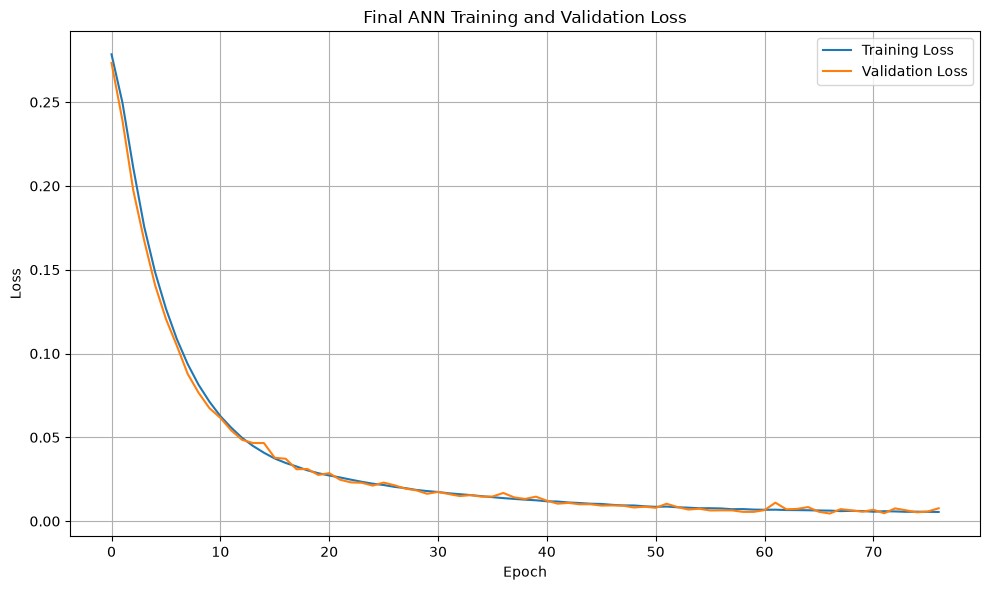

In [55]:
# ============================================================
# TRAINING / VALIDATION LOSS CURVE
# ============================================================

import matplotlib.pyplot as plt


plt.figure(figsize=(10, 6))


plt.plot(

    final_history["train_loss"],

    label="Training Loss"
)


plt.plot(

    final_history["val_loss"],

    label="Validation Loss"
)


plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Final ANN Training and Validation Loss"
)

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()

In [56]:
# ============================================================
# BEST VALIDATION PERFORMANCE
# ============================================================

best_epoch_index = np.argmin(
    final_history["val_loss"]
)

best_epoch = best_epoch_index + 1

best_train_loss = (
    final_history["train_loss"][best_epoch_index]
)

best_val_loss = (
    final_history["val_loss"][best_epoch_index]
)


print("\n==============================================")
print("BEST VALIDATION PERFORMANCE")
print("==============================================")

print(
    f"Best epoch       : {best_epoch}"
)

print(
    f"Training loss    : {best_train_loss:.6f}"
)

print(
    f"Validation loss  : {best_val_loss:.6f}"
)


BEST VALIDATION PERFORMANCE
Best epoch       : 67
Training loss    : 0.006287
Validation loss  : 0.004553


In [57]:
# ============================================================
# FINAL MODEL PREDICTIONS
# ============================================================

final_train_predictions_scaled = predict(

    final_model,

    X_train
)


final_val_predictions_scaled = predict(

    final_model,

    X_val
)


final_test_predictions_scaled = predict(

    final_model,

    X_test
)


# ============================================================
# INVERSE TARGET SCALING
# ============================================================

if target_scaler is not None:

    final_train_predictions = (
        target_scaler
        .inverse_transform(
            final_train_predictions_scaled.reshape(-1, 1)
        )
        .flatten()
    )

    final_val_predictions = (
        target_scaler
        .inverse_transform(
            final_val_predictions_scaled.reshape(-1, 1)
        )
        .flatten()
    )

    final_test_predictions = (
        target_scaler
        .inverse_transform(
            final_test_predictions_scaled.reshape(-1, 1)
        )
        .flatten()
    )


    final_y_train = (
        target_scaler
        .inverse_transform(
            y_train.reshape(-1, 1)
        )
        .flatten()
    )

    final_y_val = (
        target_scaler
        .inverse_transform(
            y_val.reshape(-1, 1)
        )
        .flatten()
    )

    final_y_test = (
        target_scaler
        .inverse_transform(
            y_test.reshape(-1, 1)
        )
        .flatten()
    )


else:

    final_train_predictions = (
        final_train_predictions_scaled
    )

    final_val_predictions = (
        final_val_predictions_scaled
    )

    final_test_predictions = (
        final_test_predictions_scaled
    )

    final_y_train = y_train

    final_y_val = y_val

    final_y_test = y_test


# ============================================================
# CALCULATE METRICS
# ============================================================

train_metrics = calculate_metrics(

    final_y_train,

    final_train_predictions
)


val_metrics = calculate_metrics(

    final_y_val,

    final_val_predictions
)


test_metrics = calculate_metrics(

    final_y_test,

    final_test_predictions
)


# ============================================================
# DISPLAY METRICS
# ============================================================

print("\n==============================================")
print("FINAL ANN PERFORMANCE")
print("==============================================")


print("\nTRAINING SET")

for metric, value in train_metrics.items():

    print(
        f"{metric:10s}: {value:.6f}"
    )


print("\nVALIDATION SET")

for metric, value in val_metrics.items():

    print(
        f"{metric:10s}: {value:.6f}"
    )


print("\nTEST SET")

for metric, value in test_metrics.items():

    print(
        f"{metric:10s}: {value:.6f}"
    )


FINAL ANN PERFORMANCE

TRAINING SET
MSE       : 8558.889648
RMSE      : 92.514267
MAE       : 57.739445
R2        : 0.991029

VALIDATION SET
MSE       : 8687.815430
RMSE      : 93.208451
MAE       : 58.399113
R2        : 0.991199

TEST SET
MSE       : 8686.439453
RMSE      : 93.201070
MAE       : 57.898319
R2        : 0.990647


In [58]:
# ============================================================
# METRICS TABLE
# ============================================================

metrics_table = pd.DataFrame({

    "Metric": list(test_metrics.keys()),

    "Train": list(train_metrics.values()),

    "Validation": list(val_metrics.values()),

    "Test": list(test_metrics.values())

})


print("\n==============================================")
print("PERFORMANCE METRICS TABLE")
print("==============================================")

display(metrics_table)


PERFORMANCE METRICS TABLE


,Metric,Train,Validation,Test
0,MSE,8558.889648,8687.815430,8686.439453
1,RMSE,92.514267,93.208451,93.201070
2,MAE,57.739445,58.399113,57.898319
3,R2,0.991029,0.991199,0.990647


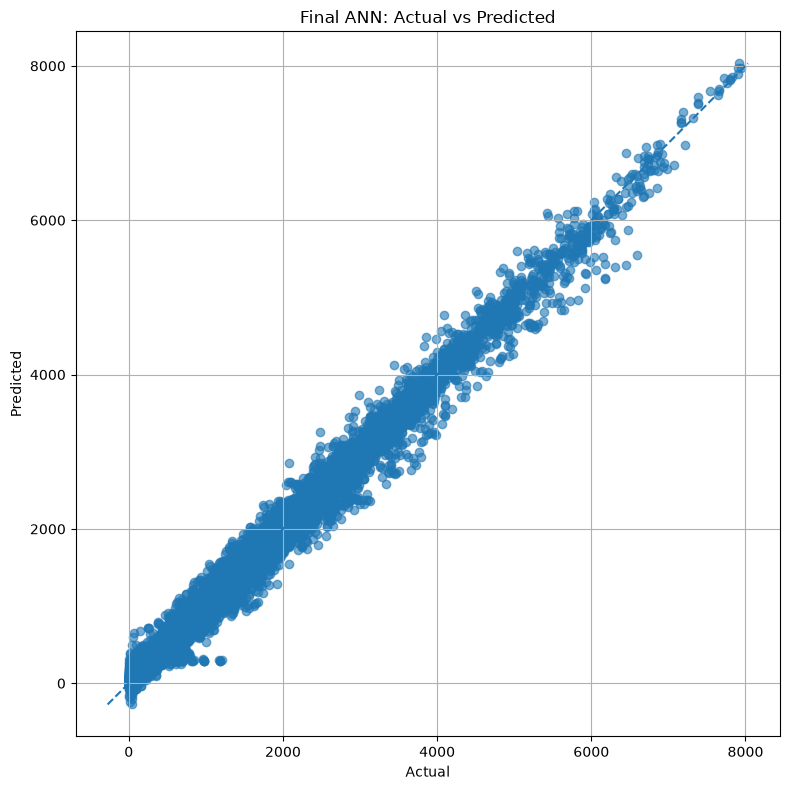

In [59]:
# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(8, 8))


plt.scatter(

    final_y_test,

    final_test_predictions,

    alpha=0.6
)


# Perfect prediction line

minimum_value = min(

    final_y_test.min(),

    final_test_predictions.min()
)


maximum_value = max(

    final_y_test.max(),

    final_test_predictions.max()
)


plt.plot(

    [minimum_value, maximum_value],

    [minimum_value, maximum_value],

    linestyle="--"
)


plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Final ANN: Actual vs Predicted"
)


plt.grid(True)

plt.tight_layout()

plt.show()

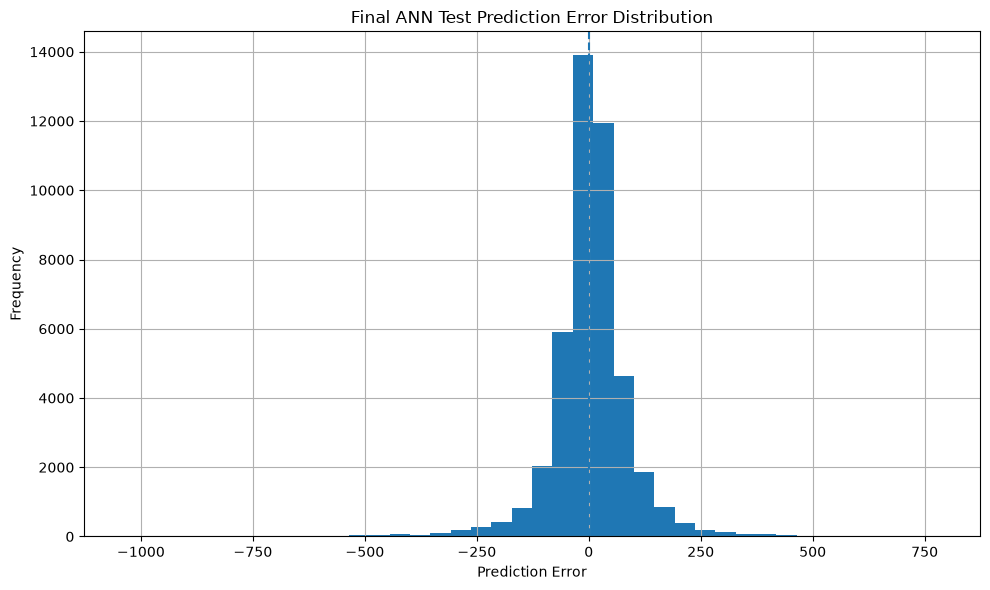

In [60]:
# ============================================================
# TEST ERROR DISTRIBUTION
# ============================================================

test_errors = (
    final_test_predictions
    - final_y_test
)


plt.figure(figsize=(10, 6))


plt.hist(

    test_errors,

    bins=40
)


plt.axvline(

    0,

    linestyle="--"
)


plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.title(
    "Final ANN Test Prediction Error Distribution"
)


plt.grid(True)

plt.tight_layout()

plt.show()

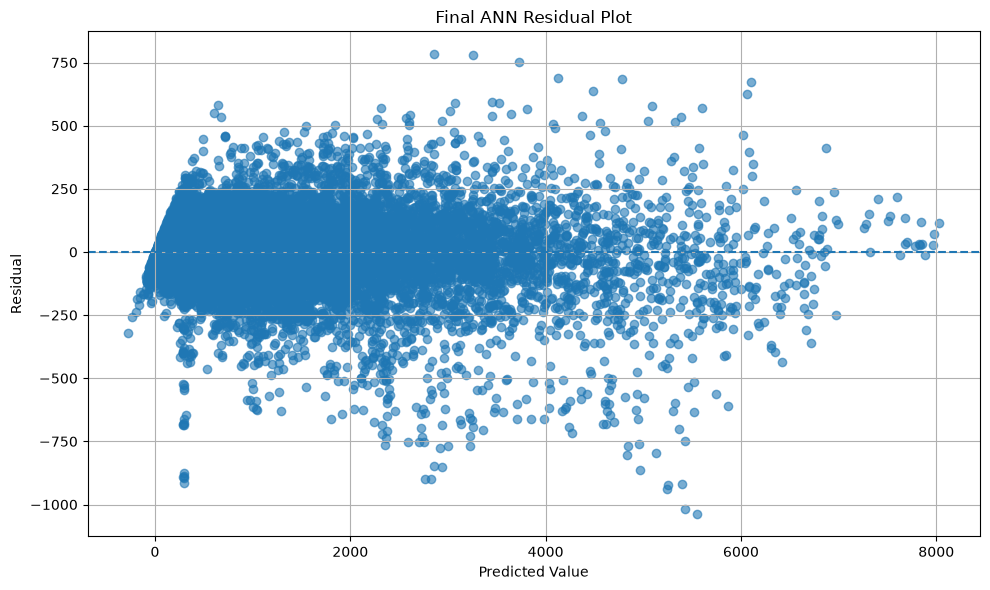

In [61]:
# ============================================================
# RESIDUAL PLOT
# ============================================================

plt.figure(figsize=(10, 6))


plt.scatter(

    final_test_predictions,

    test_errors,

    alpha=0.6
)


plt.axhline(

    0,

    linestyle="--"
)


plt.xlabel("Predicted Value")

plt.ylabel("Residual")

plt.title(
    "Final ANN Residual Plot"
)


plt.grid(True)

plt.tight_layout()

plt.show()

In [62]:
# ============================================================
# SAVE FINAL MODEL
# ============================================================

MODEL_PATH = "FINAL_ANN_WEC_MODEL.pth"


torch.save({

    "model_state_dict":
        final_model.state_dict(),

    "input_size":
        X_train.shape[1],

    "hidden_layers":
        FINAL_HIDDEN_LAYERS,

    "output_size":
        1,

    "activation":
        FINAL_ACTIVATION,

    "dropout":
        FINAL_DROPOUT,

    "learning_rate":
        FINAL_LEARNING_RATE,

    "batch_size":
        FINAL_BATCH_SIZE,

    "optimizer":
        FINAL_OPTIMIZER,

    "loss":
        FINAL_LOSS,

    "weight_decay":
        FINAL_WEIGHT_DECAY,

    "best_epoch":
        best_epoch,

    "best_val_loss":
        best_val_loss,

    "test_metrics":
        test_metrics

}, MODEL_PATH)


print(
    f"\nFinal model saved to: {MODEL_PATH}"
)


Final model saved to: FINAL_ANN_WEC_MODEL.pth


In [63]:
# ============================================================
# SAVE PREPROCESSING OBJECTS
# ============================================================

import joblib


joblib.dump(

    input_scaler,

    "FINAL_ANN_FEATURE_SCALER.pkl"
)


joblib.dump(

    target_scaler,

    "FINAL_ANN_TARGET_SCALER.pkl"
)


print(
    "Feature and target scalers saved."
)

Feature and target scalers saved.


In [64]:
# ============================================================
# SAVE METRICS
# ============================================================

metrics_table.to_csv(

    "FINAL_ANN_METRICS.csv",

    index=False
)


# ============================================================
# SAVE CONFIGURATION
# ============================================================

configuration_table = pd.DataFrame({

    "Parameter": [

        "Hidden Layers",
        "Learning Rate",
        "Batch Size",
        "Activation",
        "Dropout",
        "Optimizer",
        "Loss",
        "Weight Decay",
        "Input Features",
        "Output Features",
        "Total Parameters",
        "Best Epoch",
        "Best Validation Loss"
    ],

    "Value": [

        str(FINAL_HIDDEN_LAYERS),
        FINAL_LEARNING_RATE,
        FINAL_BATCH_SIZE,
        FINAL_ACTIVATION,
        FINAL_DROPOUT,
        FINAL_OPTIMIZER,
        FINAL_LOSS,
        FINAL_WEIGHT_DECAY,
        X_train.shape[1],
        1,
        total_parameters,
        best_epoch,
        best_val_loss
    ]

})


configuration_table.to_csv(

    "FINAL_ANN_CONFIGURATION.csv",

    index=False
)


print(
    "Metrics and configuration saved."
)

Metrics and configuration saved.


In [65]:
# ============================================================
# FINAL EXPERIMENT SUMMARY
# ============================================================

experiment_summary = pd.DataFrame({

    "Architecture":
        [str(FINAL_HIDDEN_LAYERS)],

    "Learning Rate":
        [FINAL_LEARNING_RATE],

    "Batch Size":
        [FINAL_BATCH_SIZE],

    "Activation":
        [FINAL_ACTIVATION],

    "Dropout":
        [FINAL_DROPOUT],

    "Optimizer":
        [FINAL_OPTIMIZER],

    "Loss":
        [FINAL_LOSS],

    "Weight Decay":
        [FINAL_WEIGHT_DECAY],

    "Best Epoch":
        [best_epoch],

    "Best Validation Loss":
        [best_val_loss],

    "Test MSE":
        [test_metrics.get("MSE", np.nan)],

    "Test RMSE":
        [test_metrics.get("RMSE", np.nan)],

    "Test MAE":
        [test_metrics.get("MAE", np.nan)],

    "Test R2":
        [test_metrics.get("R2", np.nan)]

})


print("\n==============================================")
print("FINAL EXPERIMENT SUMMARY")
print("==============================================")

display(experiment_summary)


FINAL EXPERIMENT SUMMARY


,Architecture,Learning Rate,Batch Size,Activation,Dropout,Optimizer,Loss,Weight Decay,Best Epoch,Best Validation Loss,Test MSE,Test RMSE,Test MAE,Test R2
0,"[128, 64, 32]",0.0005,64,tanh,0.0,adam,huber,0.0,67,0.004553,8686.439453,93.20107,57.898319,0.990647
